# Линейная алгебра, математический анализ

### 1. Линейная алгебра

1. Даны матрицы

$$
A =
\begin{pmatrix}
2 & -4 \\
3 & 5 \\
-1 & 0
\end{pmatrix}
,
\quad
B = 
\begin{pmatrix}
1 & 2 & 7 \\
-3 & -4 & 0 \\
5 & 2 & 1
\end{pmatrix}
,
\quad
C = 
\begin{pmatrix}
6 & -3 & 9 \\
4 & -5 & 2 \\
8 & 1 & 5
\end{pmatrix}
$$

Посчитайте матрицу $D = A^{T}С - 2A^{T}B^{T}$. Приведите полную последовательность вычислений.

In [3]:
from sympy import Matrix, solve, latex, init_printing
from IPython.display import display, Math

init_printing()

A = Matrix([
    [2, -4],
    [3, 5],
    [-1, 0]])

B = Matrix([
    [1, 2, 7],
    [-3, -4, 0],
    [5, 2, 1]])

C = Matrix([
    [6, -3, 9],
    [4, -5, 2],
    [8, 1, 5]])

display(Math(f"""
    A = {latex(A, mat_delim="(")},
    B = {latex(B, mat_delim="(")},
    C = {latex(C, mat_delim="(")} \\\\[1em]
    A^T = {latex(A.T, mat_delim="(")}, 
    B^T = {latex(B.T, mat_delim="(")} \\\\[1em]
    A^T \\times C = {latex(A.T, mat_delim="(")} \\times {latex(C, mat_delim="(")} 
          = {latex(A.T * C, mat_delim="(")} \\\\[1em]
    2 A^T B^T = 2 \\cdot \\left( {latex(A.T, mat_delim="(")} \\times {latex(B.T, mat_delim="(")} \\right)
              = 2 \\cdot {latex(A.T * B.T, mat_delim="(")}
              = {latex(2 * A.T * B.T, mat_delim="(")} \\\\[1em]
    D = A^T C - 2 A^T B^T = {latex(A.T * C, mat_delim="(")} - {latex(2 * A.T * B.T, mat_delim="(")} 
      = {latex(A.T * C - 2 * A.T * B.T, mat_delim="(")}
    """))

<IPython.core.display.Math object>

2. Дано выражение

$$
3 \cdot
\begin{pmatrix}
x & 2 & 3 \\
-1 & y & 4
\end{pmatrix}
+
2 \cdot
\begin{pmatrix}
1 & 2 & -5 \\
2 & -6 & z
\end{pmatrix}
=
\begin{pmatrix}
8 & v & -1 \\
1 & 6 & 4
\end{pmatrix}
$$

Найдите значения $x$, $y$, $z$ и $v$, при которых выражение верно.

In [54]:
from sympy import Matrix, symbols, solve, Eq, init_printing, latex
from IPython.display import display, Math

init_printing()

x, y, z, v = symbols("x y z v")

A = Matrix([
    [x, 2, 3],
    [-1, y, 4]
])

B = Matrix([
    [1, 2, -5],
    [2, -6, z]
])

C = Matrix([
    [8, v, -1],
    [1, 6, 4]
])

equation = 3 * A + 2 * B - C
rows, cols = equation.shape
equations = [Eq(equation[i, j], 0) for j in range(cols) for i in range(rows)]
equations = [e for e in equations if e != True]

solution = solve(equations, (x, y, z, v))

display(Math(f"""
    Исходное \\ выражение: \\\\[1em]
    3 \\cdot {latex(A, mat_delim="(")} + 2 \\cdot {latex(B, mat_delim="(")}
    = {latex(C, mat_delim="(")} \\\\[1em]
    {latex(3 * A, mat_delim="(")} + {latex(2 * B, mat_delim="(")} - {latex(C, mat_delim="(")} = 0 \\\\[1em]
    {latex(3 * A + 2 * B - C, mat_delim="(")} = 0 \\\\[1em]
    Выделим \\ и \\ решим \\ систему \\ линейных \\ уравнений: \\\\[1em]
    \\begin{{cases}}
    {'; \\\\'.join([latex(e) for e in equations])}
    \\end{{cases}} \\\\[1em]
    Т.к. \\ все \\ уравнения \\ однозначны, \\ легко \\ найти \\ все \\ неизвестные: \\\\[1em]
    \\begin{{cases}}
    {'; \\\\'.join([f"{latex(var)} = {latex(val)}" for var, val in solution.items()])}
    \\end{{cases}} \\\\[1em]
"""))

<IPython.core.display.Math object>

3. Укажите те значения параметров p и q, при которых ранг матрицы 
$A = \begin{pmatrix} 
1 & 2 & 3 \\
3 & 6 & p \\
5 & 10 & q
\end{pmatrix}$
равен единице.

In [55]:
from sympy import Matrix, symbols, latex, solve, Eq, init_printing
from IPython.display import display, Math

init_printing()

p, q = symbols("p q")

A = Matrix([
    [1, 2, 3],
    [3, 6, p],
    [5, 10, q]
])

equations = [
    Eq(A[[0, 1], [1, 2]].det(), 0),
    Eq(A[[0, 2], [1, 2]].det(), 0)
]

solution = solve(equations, (p, q))

display(Math(f"""
    A(p, q) = {latex(A, mat_delim="(")} \\\\[1em]
    Для \\ того, \\ чтобы \\ ранг \\ был \\ равен \\ 1, \\ 
    нужно \\ чтобы \\ все \\ миноры \\ 2-го \\ порядка \\ были \\ равны \\ 0 \\\\[1em]
    Для \\ начала \\ выделим \\ все \\ миноры \\ в \\ части \\ матрицы \\ с \\ известными \\ 
    {latex(A[:, :2], mat_delim="(")}, а \\ именно: \\\\[1em]
    detM_1 = \\left{"|"}{latex(A[[0, 1], [0, 1]], mat_delim="")}\\right{"|"} = {latex(A[[0, 1], [0, 1]].det())},
    detM_2 = \\left{"|"}{latex(A[[0, 2], [0, 1]], mat_delim="")}\\right{"|"} = {latex(A[[0, 2], [0, 1]].det())},
    detM_3 = \\left{"|"}{latex(A[[1, 2], [0, 1]], mat_delim="")}\\right{"|"} = {latex(A[[0, 2], [0, 1]].det())} \\\\[1em]
    Как \\ видно, \\ миноры \\ равны \\ нулю, \\ соответственно, \\ остальные \\ миноры \\ части \\ матрицы \\ 
    {latex(A[:, 1:3], mat_delim="(")} так \\ же \\ должны \\ равнятся \\ нулю. \\\\[1em]
    По \\ аналогии \\ выделим \\ все \\ миноры: \\\\[1em]
    detM_4 = \\left{"|"}{latex(A[[0, 1], [1, 2]], mat_delim="")}\\right{"|"} = {latex(A[[0, 1], [1, 2]].det())} = 0,
    detM_5 = \\left{"|"}{latex(A[[0, 2], [1, 2]], mat_delim="")}\\right{"|"} = {latex(A[[0, 2], [1, 2]].det())} = 0,
    detM_6 = \\left{"|"}{latex(A[[1, 2], [1, 2]], mat_delim="")}\\right{"|"} = {latex(A[[1, 2], [1, 2]].det())} = 0 \\\\[1em]    
    миноры \\ M_4, \\ M_5 \\ и \\ M_6 \\ можно \\ выделить \\ в \\ СЛАУ: \\\\[1em]
    \\begin{{cases}}
    {latex(A[[0, 1], [1, 2]].det())} = 0; \\\\
    {latex(A[[0, 2], [1, 2]].det())} = 0; \\\\
    {latex(A[[1, 2], [1, 2]].det())} = 0
    \\end{{cases}} \\\\[1em]
    Решение \\ данной \\ СЛАУ \\ однозначно \\ и \\ легко \\ увидеть, \\ что \\
    \\operatorname{{rank}} \\bigl( A(p, q) \\bigr) = 1 \\iff 
    \\begin{{cases}}
    {'; \\\\'.join([f"{latex(var)} = {latex(val)}" for var, val in solution.items()])}
    \\end{{cases}} \\\\[1em]    
"""))

<IPython.core.display.Math object>

4. Относительно канонического (стандартного) базиса в $\mathbb{R}^2$ даны три вектора $a_1 = (2, −5)^⊤$, $a_2 = (−1, 3)^⊤$
и $x = (1, −4)^⊤$. Примите векторы $a_1, a_2$ за новый базис $B$, предварительно проверив, что они линейно
независимы.\
(a) Найдите координаты вектора $[x]_B$ вектора $x$ в новом базисе.\
(b) Предположим, что координаты вектора $y$ в базисе $B$ заданы $[y]_B = (1, 1)^T$. 
Найдите координаты вектора $y$ в стандартном базисе.

In [181]:
from sympy import Matrix, symbols, Eq, solve
from IPython.display import Math, display

alpha, beta = symbols("alpha beta")

e1 = Matrix([1, 0])
e2 = Matrix([0, 1])
a1 = Matrix([2, -5])
a2 = Matrix([-1, 3])
B = a1.row_join(a2).T
x = Matrix([1, -4])
xb = Matrix([alpha, beta])
y = Matrix([1, 1])

eq_a = Eq(xb[0] * a1 + xb[1] * a2, x)
solution_a = solve(eq_a, (alpha, beta))
eq_b = y[0] * a1 + y[1] * a2


display(Math(f"""
    Канонический \\ базис \\ здесь \\ 
    e_1 =\\begin{{pmatrix}} 1 \\\\ 0 \\end{{pmatrix}} \\ и \\
    e_2 =\\begin{{pmatrix}} 0 \\\\ 1 \\end{{pmatrix}} \\Rightarrow
    Для \\ нахождения \\ вектора \\ {latex(x, mat_delim="(")} \\ 
    в \\ каноническом \\ базисе \\ используется \\ формула: \\\\[1em]
    [x] = x_1 \\cdot e_1 + x_2 \\cdot e_2 = 
    {latex(x[0])} \\cdot {latex(e1, mat_delim="(")} + ({latex(x[1])}) \\cdot {latex(e2, mat_delim="(")} = 
    {latex(x[0] * e1 + x[1] * e2, mat_delim="(")} \\\\[1em]
    Чтобы \\ найти \\ этот \\ же \\ вектор \\ в \\ новом \\ базисе \\ 
    B = {latex(B, mat_delim="(")}, \\ покажем, \\ что \\ определитель \\ не \\ равен \\ нулю: \\
    detB = {latex(B.det())} \\\\[1em]
    Перепишем \\ формулу \\ для \\ определения \\ вектора {latex(x, mat_delim="(")} в \\ новом \\ базисе: \\\\[1em]
    [x]_B = \\alpha \\cdot a_1 + \\beta \\cdot a_2 
          = \\alpha \\cdot {latex(a1, mat_delim="(")} + \\beta \\cdot {latex(a2, mat_delim="(")} \\\\[1em]
    Итоговое \\ уравнение \\ будет \\ иметь \\ вид: \\\\[1em]
    \\alpha \\cdot {latex(a1, mat_delim="(")} + \\beta \\cdot {latex(a2, mat_delim="(")} 
    = {latex(x, mat_delim="(")} \\\\[1em]
    Преобразуем \\ в \\ СЛАУ: \\\\[1em]
    (a) \\begin{{cases}}
    {"; \\\\".join([f"{latex(eq)} = {latex(eq_a.rhs[i])}" for i, eq in enumerate(eq_a.lhs)])}
    \\end{{cases}} \\Rightarrow
    [x]_B = \\begin{{pmatrix}} {latex(solution_a[alpha])} \\\\ {latex(solution_a[beta])} \\end{{pmatrix}} \\\\[1em]
    (b) \\ [y] = y_1 \\cdot a_1 + y_2 \\cdot a_2 
    = {latex(y[0])} \\cdot {latex(a1, mat_delim="(")} + {latex(y[1])} \\cdot {latex(a2, mat_delim="(")}
    = {latex(eq_b, mat_delim="(")}
"""))


<IPython.core.display.Math object>

5. Исследовательское задание: малоранговая аппроксимация матрицы. Сгенерируйте случайную квадратную матрицу $A ∈ \mathbb{R}^{n×n}, n ≥ 100$. С помощью функции $numpy.linalg.svd$ выполните сингулярное разложение этой матрицы, и получите три матрицы: $U, S, V^⊤$. Выполняйте аппроксимацию матрицы $\bar{A}$ с
рангом $r$, меняя его значение, например, от $2$ до $n$:

    $\bar{A} = U[:, :r] S[:r, :r] V^T[:r, :]$,

    и каждый раз считайте ошибку апроксимации (как восстановленная матрица отличается от исходной):

    $E(r) = \|A - \bar{A}\|_F = \sqrt{\sum\limits_{i=1}^{n} \sum\limits_{j=1}^{n} (a_{ij} - \bar{a}_{ij})^2}$

    Используя библиотеку $matplotlib$, постройте график зависимости ошибки аппроксимации матрицы от ранга $r$.

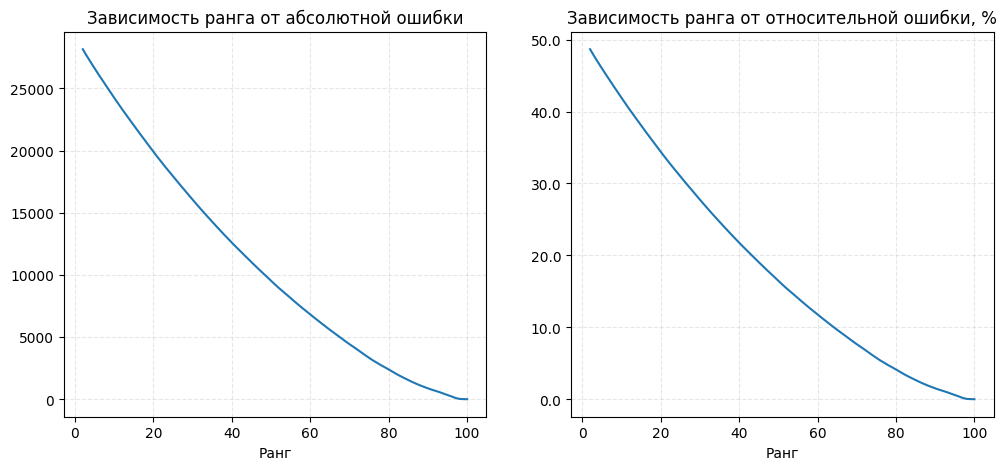

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def approximation(A, r):
    U, sigma, Vt = np.linalg.svd(A, full_matrices=True)
    S = np.diag(sigma)
    U = U[:, :r]
    S = S[:r, :r]
    Vt = Vt[:r, :]
    
    A_ = U @ S @ Vt
    return A_

n = 100
A = np.random.randint(0, 1000, (n, n))

error = {"abs": [], "rel": [], "rank": []}
for rank in range(2, n + 1):
    A_ = approximation(A, rank)
    absolute = np.linalg.norm(A - A_)
    error["abs"].append(absolute)

    relative = absolute / np.linalg.norm(A)
    error["rel"].append(relative)

    error["rank"].append(rank)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(error["rank"], error["abs"])
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.set_title("Зависимость ранга от абсолютной ошибки")
ax1.set_xlabel("Ранг")

ax2.plot(error["rank"], error["rel"])
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.set_title("Зависимость ранга от относительной ошибки, %")
ax2.set_xlabel("Ранг")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*100:.01f}"))
plt.show()